# Decode Position From Spikes

In this notebook, we will move from spatial firing maps to population decoding. The first step is to convert the mouse's 2D position on the X-maze into a 1D position along the track graph.


## 0. Setup

We will use the same DANDI session format as in the first tutorial, plus `track_linearization` to convert 2D `(x, y)` positions into a 1D coordinate along the maze.


In [2]:
%config InlineBackend.figure_format = 'retina'

import importlib
import json
import subprocess
import sys
import warnings
from pathlib import Path

PACKAGE_IMPORTS = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'pillow': 'PIL',
    'seaborn': 'seaborn',
    'dandi': 'dandi',
    'pynwb': 'pynwb',
    'remfile': 'remfile',
    'h5py': 'h5py',
    'scipy': 'scipy',
    'scikit-learn': 'sklearn',
    'track-linearization': 'track_linearization',
}

# In Colab, only this notebook file is available locally, so the companion
# helper module has to be fetched from GitHub before it can be imported.
if 'google.colab' in sys.modules and not Path('tutorial_utils.py').exists():
    import urllib.request

    TUTORIAL_UTILS_URL = (
        'https://raw.githubusercontent.com/anirudh073/camp2026/main/'
        'tutorial_utils.py'
    )
    urllib.request.urlretrieve(TUTORIAL_UTILS_URL, 'tutorial_utils.py')
    print('Downloaded tutorial_utils.py from GitHub.')

failed = {}
for package, import_name in PACKAGE_IMPORTS.items():
    try:
        importlib.import_module(import_name)
    except Exception as exc:
        failed[package] = repr(exc)

print(f'Python executable: {sys.executable}')
print(f'Python version: {sys.version.split()[0]}')

if failed:
    print('Installing missing packages into this notebook kernel:', list(failed))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *failed])
    print('Installed. If imports still fail, restart the runtime and rerun this cell.')
else:
    print('All required packages are available in this notebook kernel.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dandi.dandiapi import DandiAPIClient
import remfile
from h5py import File
from pynwb import NWBHDF5IO
from track_linearization import get_linearized_position, make_track_graph, plot_graph_as_1D, plot_track_graph

import tutorial_utils
importlib.reload(tutorial_utils)

from tutorial_utils import (
    get_unit_spike_times as fetch_unit_spike_times,
    map_spikes_to_position_frames,
    unit_region_from_row,
)

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(
    context='notebook',
    style='ticks',
    rc={
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
    },
)

COLORS = {
    'ink': '#1f2937',
    'teal': '#14b8a6',
    'blue': '#3b82f6',
    'orange': '#f59e0b',
    'magenta': '#d946ef',
    'gray': '#cbd5e1',
}


Python executable: /home/labuser/miniforge3/envs/camp2026/bin/python
Python version: 3.12.13
Installing missing packages into this notebook kernel: ['scikit-learn']
Installed. If imports still fail, restart the runtime and rerun this cell.


## 1. Stream one session

Use one session from Dandiset `001701`. Keep the file path explicit so it is easy to swap sessions later.


In [5]:
DANDISET_ID = "001701"
DANDISET_VERSION = "0.260120.0303"

# Match tutorial 1 so the spatial coding and decoding notebooks use the same session.
asset_path = "sub-Lovelace/sub-Lovelace_ses-Lovelace-DY01-g1_behavior+ecephys.nwb"
# asset_path = "sub-Lamarr/sub-Lamarr_ses-Lamarr-DY01-g0_behavior+ecephys.nwb"


In [6]:
client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
asset = dandiset.get_asset_by_path(asset_path)
stream_url = asset.get_content_url(follow_redirects=1, strip_query=True)

remote_file = File(remfile.File(stream_url), 'r')
io = NWBHDF5IO(file=remote_file, mode='r', load_namespaces=True)
nwb = io.read()

print('Streaming NWB file:')
print(asset.path)
print('\nSession description:', nwb.session_description)
print('Identifier:', nwb.identifier)


A newer version (0.76.6) of dandi/dandi-cli is available. You are using 0.76.5


Streaming NWB file:
sub-Lovelace/sub-Lovelace_ses-Lovelace-DY01-g1_behavior+ecephys.nwb

Session description: X Maze
Identifier: AeryJones,EmilyLovelaceDY01-g1


## 2. Extract 2D position

The decoder will eventually use a 1D position. Before that, we read the original 2D position samples from the NWB file and build a time-aligned dataframe.


In [7]:
position_series = nwb.processing['behavior']['Position']['position']
position_data = position_series.data[:]
sampling_rate = position_series.rate
series_start_time = position_series.starting_time

time = series_start_time + np.arange(position_data.shape[0]) / sampling_rate
x = position_data[:, 0]
y = position_data[:, 1]

valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(time)
position_df = pd.DataFrame({
    'time': time[valid],
    'x': x[valid],
    'y': y[valid],
}).reset_index(drop=True)

print('Position samples:', len(position_df))
print('Time range:', f"{position_df['time'].iloc[0]:.2f} to {position_df['time'].iloc[-1]:.2f} s")
display(position_df.head())


Position samples: 114205
Time range: 4.44 to 1934.76 s


,time,x,y
0,4.441630,11.166757,9.683618
1,4.458297,11.184705,9.658853
2,4.474963,11.201572,9.635774
3,4.491630,11.216518,9.615696
4,4.508297,11.229099,9.599299


## 3. Summarize recorded units

Before decoding, check which brain regions are represented in this session. We will build a compact table with one row per unit, then count how many units come from each region.


In [8]:
units_table = nwb.units
unit_ids = np.asarray(units_table.id[:])
electrodes_df = nwb.electrodes.to_dataframe()

spike_time_ends = np.asarray(units_table['spike_times_index'].data[:])
total_spikes = np.diff(np.r_[0, spike_time_ends])
session_duration = position_df['time'].iloc[-1] - position_df['time'].iloc[0]
firing_rate_hz = total_spikes / session_duration
regions = [unit_region_from_row(units_table, row_i, electrodes_df) for row_i in range(len(unit_ids))]

units_df = pd.DataFrame({
    'unit_id': unit_ids,
    'region': regions,
    'total_spikes': total_spikes,
    'firing_rate_hz': firing_rate_hz,
}).set_index('unit_id')

region_counts = units_df['region'].value_counts().rename('n_units').to_frame()
print(f'Total units: {len(units_df)}')
display(region_counts)


Total units: 415


,n_units
region,
CA1,132
DG-mo,66
CA3,52
RSPagl6a,37
ccb,35
DG-sg,31
cing,28
DG-po,13
SSp-tr6b,8


## 4. Choose a brain region

Type one region name from the table above. This keeps the next steps explicit: you decide which population you want to decode from.


In [9]:
region_filter = 'CA1'

region_units = units_df[units_df['region'] == region_filter].copy().sort_index()

print(f'Region: {region_filter}')
print(f'Units in this region: {len(region_units)}')
print('Unit IDs:')
print(region_units.index.to_list())


Region: CA1
Units in this region: 132
Unit IDs:
[29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 69, 70, 71, 72, 73, 74, 75, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 128, 129, 130, 131, 145, 146, 147, 148, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 267, 268, 269, 270, 271, 272, 273, 274, 275, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347]


## 5. Choose decoding units

Now apply a simple firing-rate filter. The lower cutoff removes units with too few spikes to estimate a stable tuning curve, and the upper cutoff removes very high-rate units if you want to focus on putative principal cells.


In [10]:
min_rate_hz = 0.1
max_rate_hz = 5.0

candidate_units = region_units[
    (region_units['firing_rate_hz'] >= min_rate_hz)
    & (region_units['firing_rate_hz'] <= max_rate_hz)
].copy()

print(f'Firing-rate range: {min_rate_hz} to {max_rate_hz} Hz')
print(f'Number of decoding units: {len(candidate_units)}')
print('Candidate unit IDs:')
print(candidate_units.index.to_list())


Firing-rate range: 0.1 to 5.0 Hz
Number of decoding units: 53
Candidate unit IDs:
[30, 35, 37, 39, 40, 41, 42, 44, 47, 48, 50, 71, 102, 104, 108, 111, 113, 129, 145, 147, 148, 213, 223, 224, 228, 230, 231, 232, 233, 234, 235, 237, 240, 241, 243, 244, 247, 254, 256, 258, 270, 272, 322, 323, 324, 326, 330, 335, 336, 337, 339, 342, 345]


## 6. Load the saved track graph

The graph file stores the node coordinates and edges for the X-maze. We will reuse it here rather than redraw the maze each time.


In [11]:
graph_spec_path = Path('lovelace_track_graph_xmaze.json')
graph_spec = json.loads(graph_spec_path.read_text())

node_positions = graph_spec['node_positions']
edges = [tuple(edge) for edge in graph_spec['edges']]
track_graph = make_track_graph(node_positions, edges)

print(graph_spec_path)
print('Nodes:', len(node_positions))
print('Edges:', len(edges))


lovelace_track_graph_xmaze.json
Nodes: 6
Edges: 5


## 7. Linearize the 2D position

Map each 2D position sample onto the nearest point on the track graph. The result is a 1D coordinate along the maze, plus a track-segment label.


In [12]:
xy_position = position_df[['x', 'y']].to_numpy()

linearized = get_linearized_position(
    position=xy_position,
    track_graph=track_graph,
    edge_spacing=15.0,
)

linear_position_df = position_df.copy()
linear_position_df['linear_position'] = linearized['linear_position'].to_numpy()
linear_position_df['track_segment_id'] = linearized['track_segment_id'].to_numpy()

print(linear_position_df[['linear_position', 'track_segment_id']].head(5))


   linear_position  track_segment_id
0       113.265529                 1
1       113.278535                 1
2       113.290587                 1
3       113.300940                 1
4       113.309215                 1


## 8. Optional: 2D speed overview

Compute 2D speed from successive `(x, y)` samples.

This is useful for checking how movement varies across the session, but the linear rate maps below will use the full dataset.


In [13]:
time_2d = position_df['time'].to_numpy()
x_2d = position_df['x'].to_numpy()
y_2d = position_df['y'].to_numpy()

dx = np.diff(x_2d)
dy = np.diff(y_2d)
dt_2d = np.diff(time_2d)
distance_cm = np.sqrt(dx**2 + dy**2)
speed_mid = np.full_like(dt_2d, np.nan, dtype=float)
valid_speed = np.isfinite(distance_cm) & np.isfinite(dt_2d) & (dt_2d > 0)
speed_mid[valid_speed] = distance_cm[valid_speed] / dt_2d[valid_speed]
time_mid = time_2d[:-1] + dt_2d / 2

linear_position_df['speed_2d_cm_s'] = np.r_[np.nan, speed_mid]

print(f'Finite speed samples: {np.isfinite(speed_mid).sum()} / {len(speed_mid)}')
print(f'Mean 2D speed: {np.nanmean(speed_mid):.2f} cm/s')
print(f'Max 2D speed: {np.nanmax(speed_mid):.2f} cm/s')


Finite speed samples: 114204 / 114204
Mean 2D speed: 15.67 cm/s
Max 2D speed: 97.82 cm/s


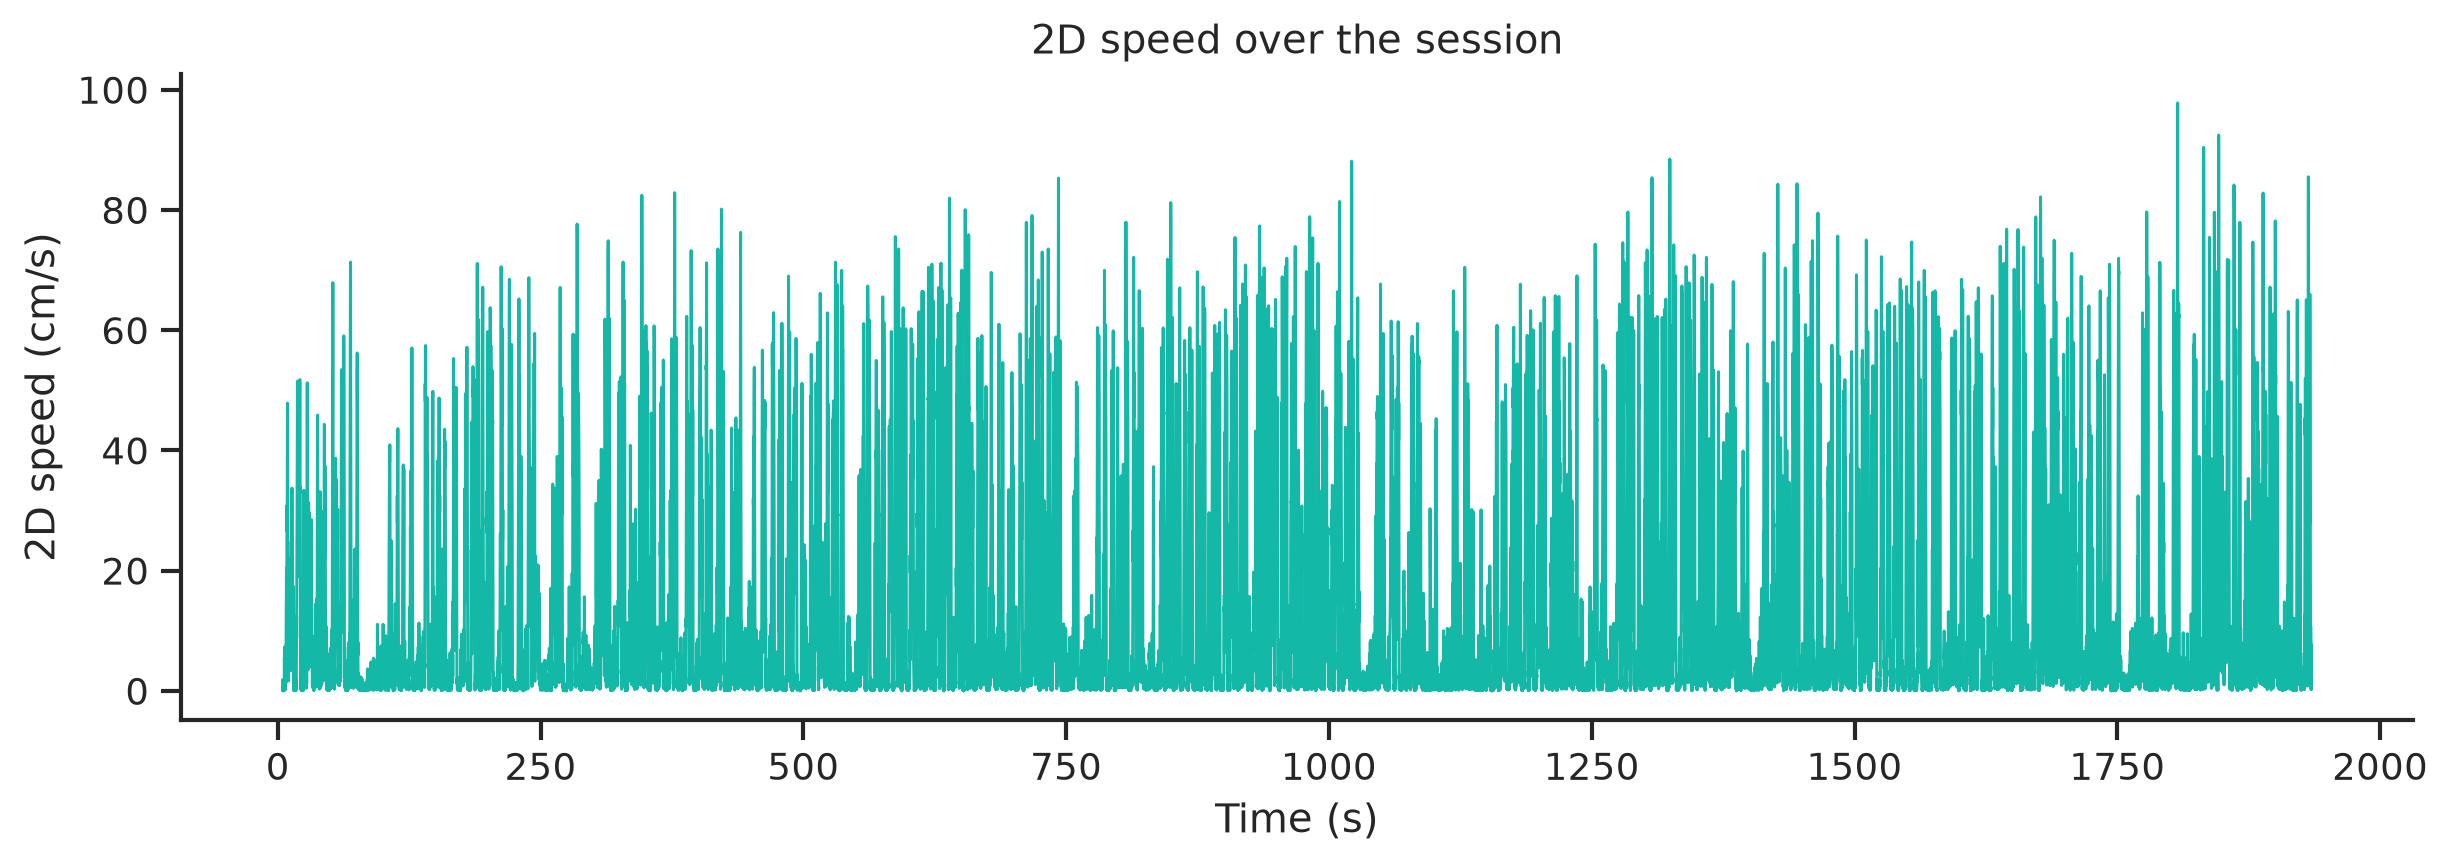

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(time_mid, speed_mid, color=COLORS['teal'], linewidth=0.9)
ax.set_xlabel('Time (s)')
ax.set_ylabel('2D speed (cm/s)')
ax.set_title('2D speed over the session')
sns.despine(ax=ax)
plt.show()


## 9. Linear rate maps for all candidate units

Now switch from 2D position to the 1D linear track and compute full-session linear rate maps for all candidate units.


In [15]:
place_bin_size_cm = 2.5
min_occupancy_s = 0.05
plot_smoothing_sigma = 1.5

def smooth_linear_rate_map(rate_map, sigma_bins=1.5):
    """Gaussian-smooth each contiguous valid linear-track segment separately."""
    radius = int(np.ceil(4 * sigma_bins))
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel = kernel / kernel.sum()

    smoothed = np.full_like(rate_map, np.nan, dtype=float)
    finite = np.isfinite(rate_map)
    if not np.any(finite):
        return smoothed

    padded = np.pad(finite.astype(int), (1, 1), constant_values=0)
    starts = np.where(np.diff(padded) == 1)[0]
    stops = np.where(np.diff(padded) == -1)[0]
    pad_width = len(kernel) // 2

    for start_i, stop_i in zip(starts, stops):
        segment = rate_map[start_i:stop_i]
        if len(segment) == 0:
            continue
        padded_segment = np.pad(segment, pad_width=pad_width, mode='edge')
        smoothed[start_i:stop_i] = np.convolve(padded_segment, kernel, mode='valid')

    return smoothed

linear_time = linear_position_df['time'].to_numpy()
linear_position = linear_position_df['linear_position'].to_numpy()

dt = np.diff(linear_time)
occupancy_position = linear_position[:-1]
occupancy_valid = np.isfinite(occupancy_position) & np.isfinite(dt)

position_min = np.nanmin(linear_position)
position_max = np.nanmax(linear_position)
linear_edges = np.arange(position_min, position_max + place_bin_size_cm, place_bin_size_cm)
linear_centers = linear_edges[:-1] + place_bin_size_cm / 2

occupancy, _ = np.histogram(
    occupancy_position[occupancy_valid],
    bins=linear_edges,
    weights=dt[occupancy_valid],
)

linear_rate_maps = []
peak_positions = []

for unit_id in candidate_units.index:
    spike_times = np.asarray(fetch_unit_spike_times(units_table, unit_ids, unit_id))
    in_range = (spike_times >= linear_time[0]) & (spike_times <= linear_time[-1])
    spike_times = spike_times[in_range]

    spike_positions = map_spikes_to_position_frames(
        spike_times,
        linear_time,
        linear_position,
        np.zeros_like(linear_position),
    )
    spike_linear_position = spike_positions['spike_x']
    spike_counts, _ = np.histogram(spike_linear_position, bins=linear_edges)

    rate_map = np.full_like(linear_centers, np.nan, dtype=float)
    occupied = occupancy > min_occupancy_s
    rate_map[occupied] = spike_counts[occupied] / occupancy[occupied]

    smoothed_rate_map = smooth_linear_rate_map(rate_map, sigma_bins=plot_smoothing_sigma)

    linear_rate_maps.append(smoothed_rate_map)
    if np.all(np.isnan(smoothed_rate_map)):
        peak_positions.append(np.nan)
    else:
        peak_positions.append(linear_centers[np.nanargmax(smoothed_rate_map)])

linear_rate_maps = np.asarray(linear_rate_maps)
peak_positions = np.asarray(peak_positions)
sort_order = np.argsort(np.nan_to_num(peak_positions, nan=np.inf))
sorted_unit_ids = candidate_units.index.to_numpy()[sort_order]
sorted_rate_maps = linear_rate_maps[sort_order]

print(f'Candidate units: {len(candidate_units)}')
print(f'Linear bins: {len(linear_centers)}')
print(f'Bin size: {place_bin_size_cm} cm')
print(f'Occupied bins: {(occupancy > min_occupancy_s).sum()}')
print(f'Gaussian smoothing sigma: {plot_smoothing_sigma} bins')

Candidate units: 53
Linear bins: 112
Bin size: 2.5 cm
Occupied bins: 92
Gaussian smoothing sigma: 1.5 bins


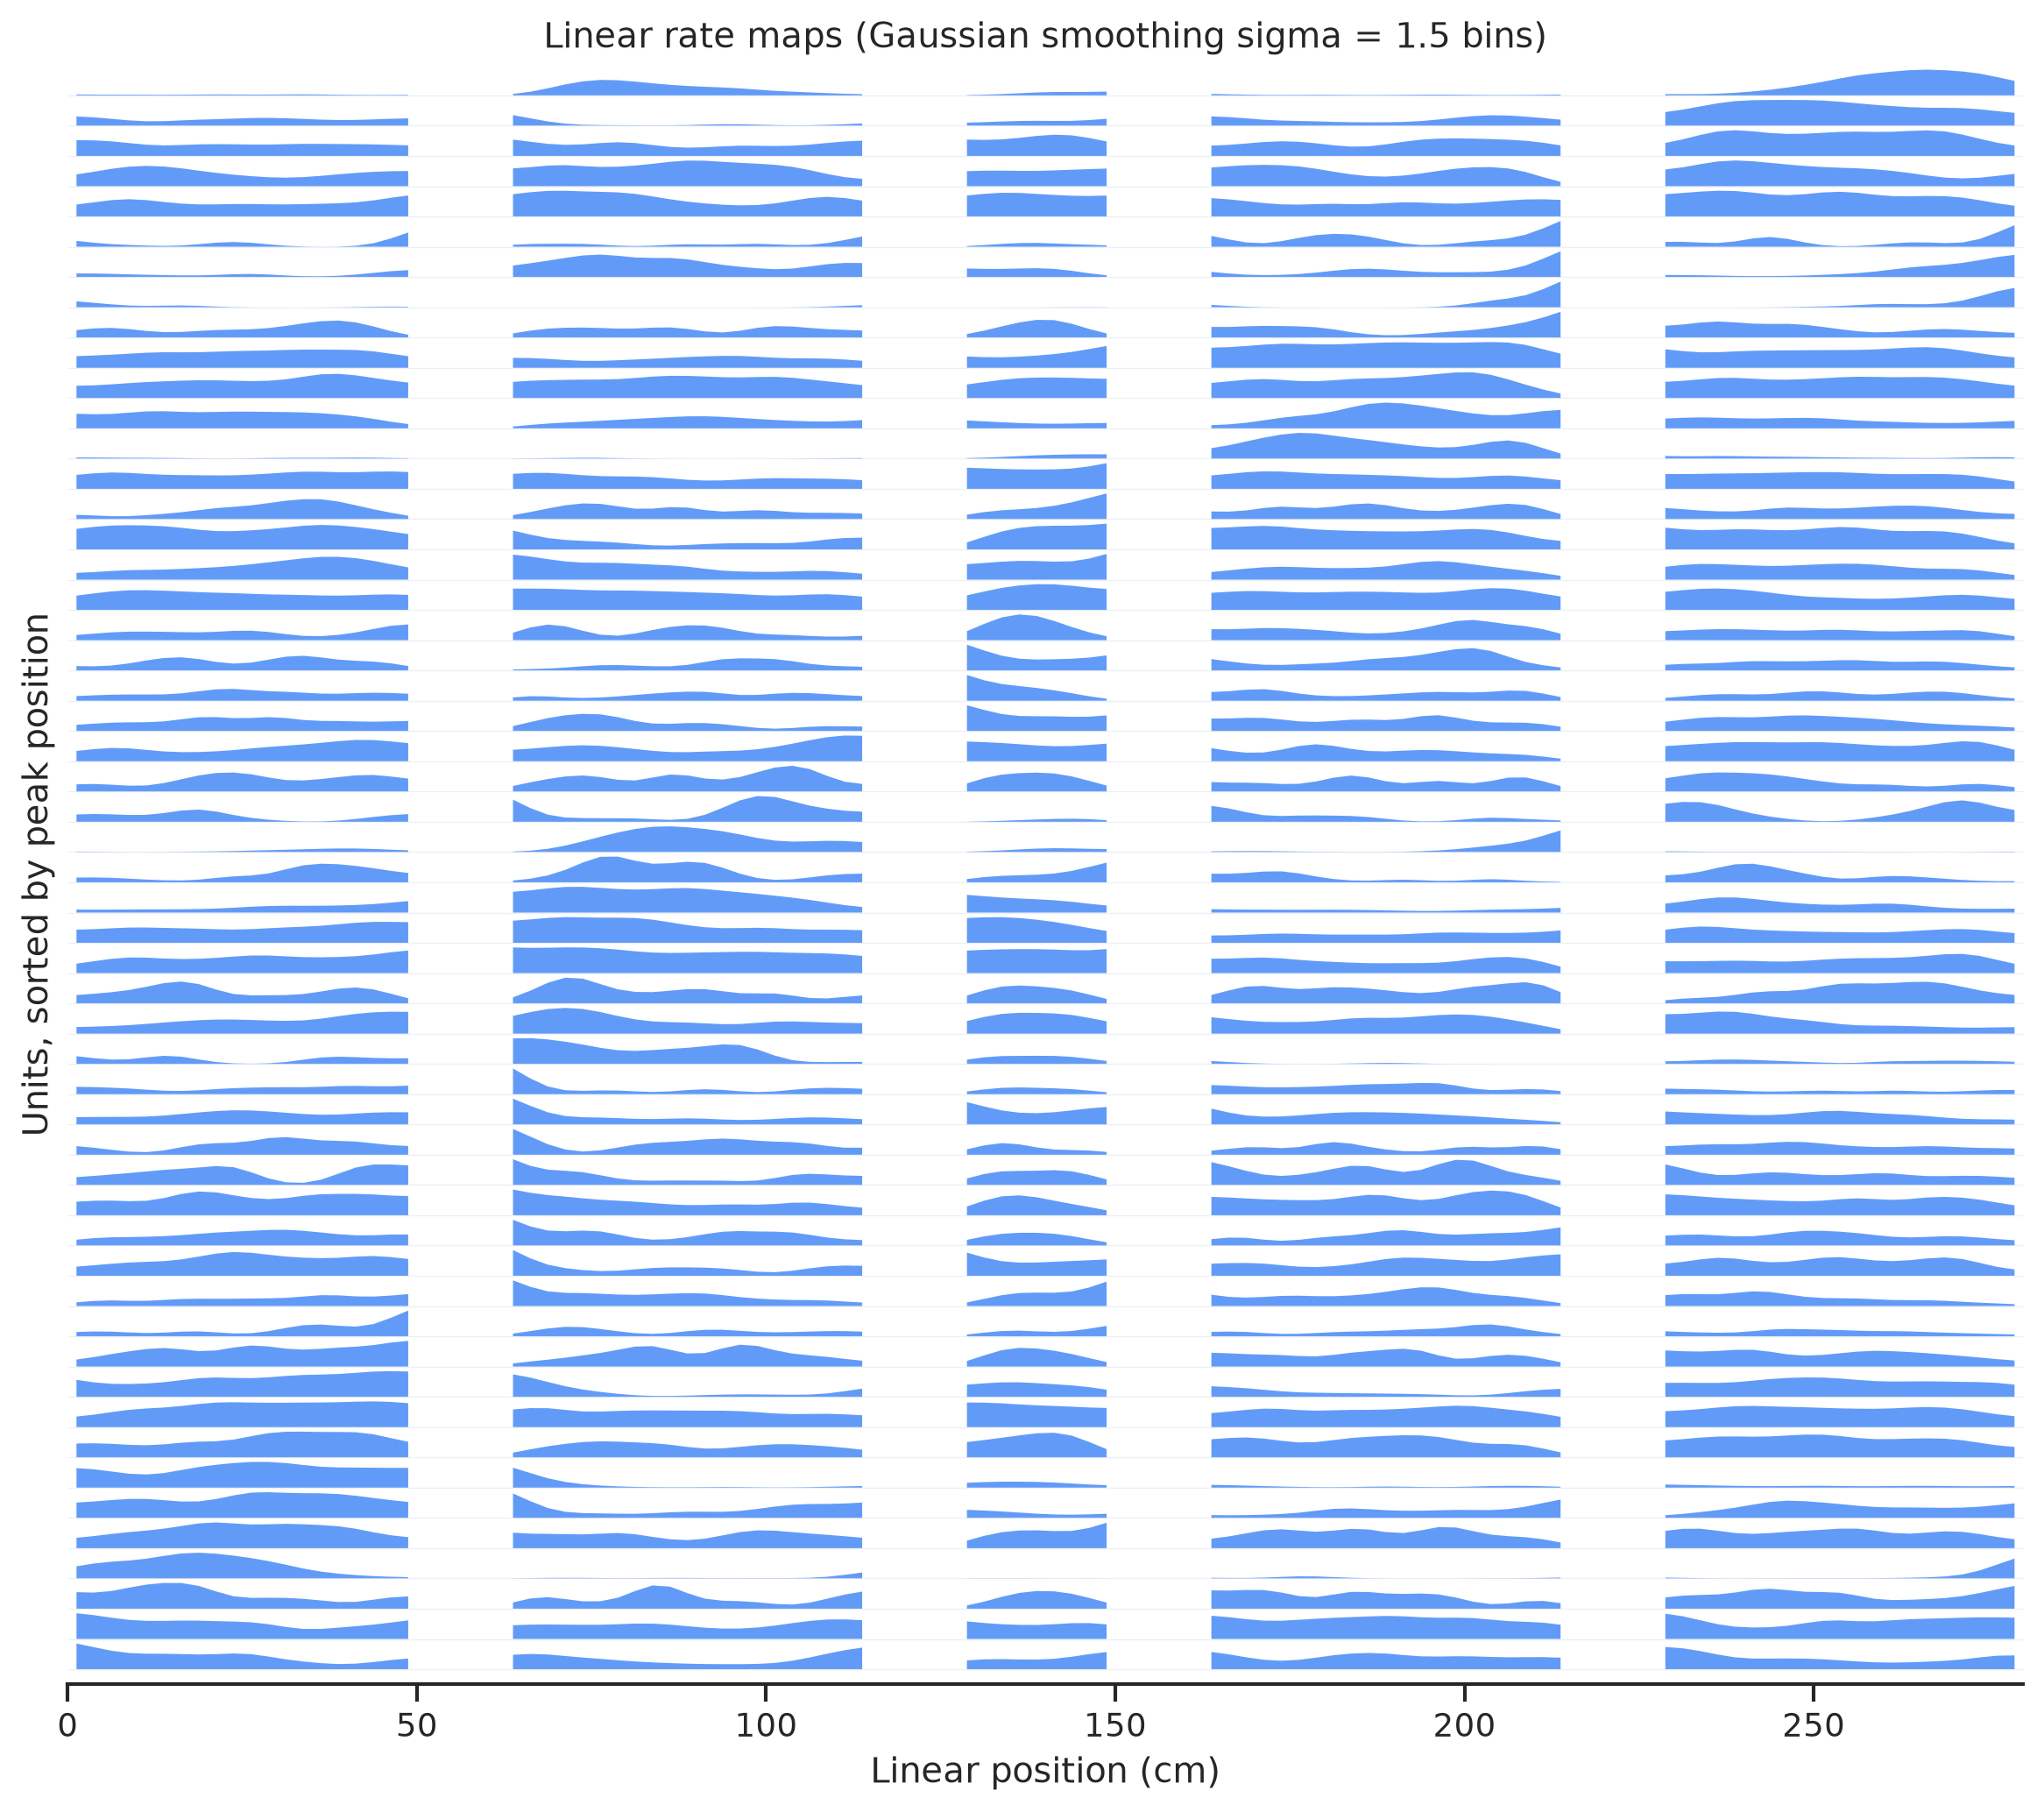

In [16]:
fig_height = max(10, 0.18 * len(sorted_unit_ids))
fig, ax = plt.subplots(figsize=(12, fig_height))

row_step = 1.0
amplitude_scale = 0.85

for row_i, rate_map in enumerate(sorted_rate_maps):
    baseline = row_i * row_step
    ax.hlines(baseline, linear_edges[0], linear_edges[-1], color=COLORS['gray'], linewidth=0.4, alpha=0.35)

    finite = np.isfinite(rate_map)
    if not np.any(finite):
        continue

    map_max = np.nanmax(rate_map)
    if map_max <= 0:
        continue

    scaled_map = baseline + amplitude_scale * (rate_map / map_max)
    ax.fill_between(
        linear_centers,
        baseline,
        scaled_map,
        where=finite,
        color=COLORS['blue'],
        alpha=0.8,
        linewidth=0,
    )

ax.set_xlim(linear_edges[0], linear_edges[-1])
ax.set_ylim(-0.5, len(sorted_unit_ids) * row_step)
ax.set_xlabel('Linear position (cm)')
ax.set_ylabel('Units, sorted by peak position')
ax.set_title(f'Linear rate maps (Gaussian smoothing sigma = {plot_smoothing_sigma:.1f} bins)')
ax.set_yticks([])
sns.despine(ax=ax, left=True)
plt.show()

## 10. Sanity checks

Before decoding, check that the graph lies on top of the maze correctly and that the 1D layout looks sensible.


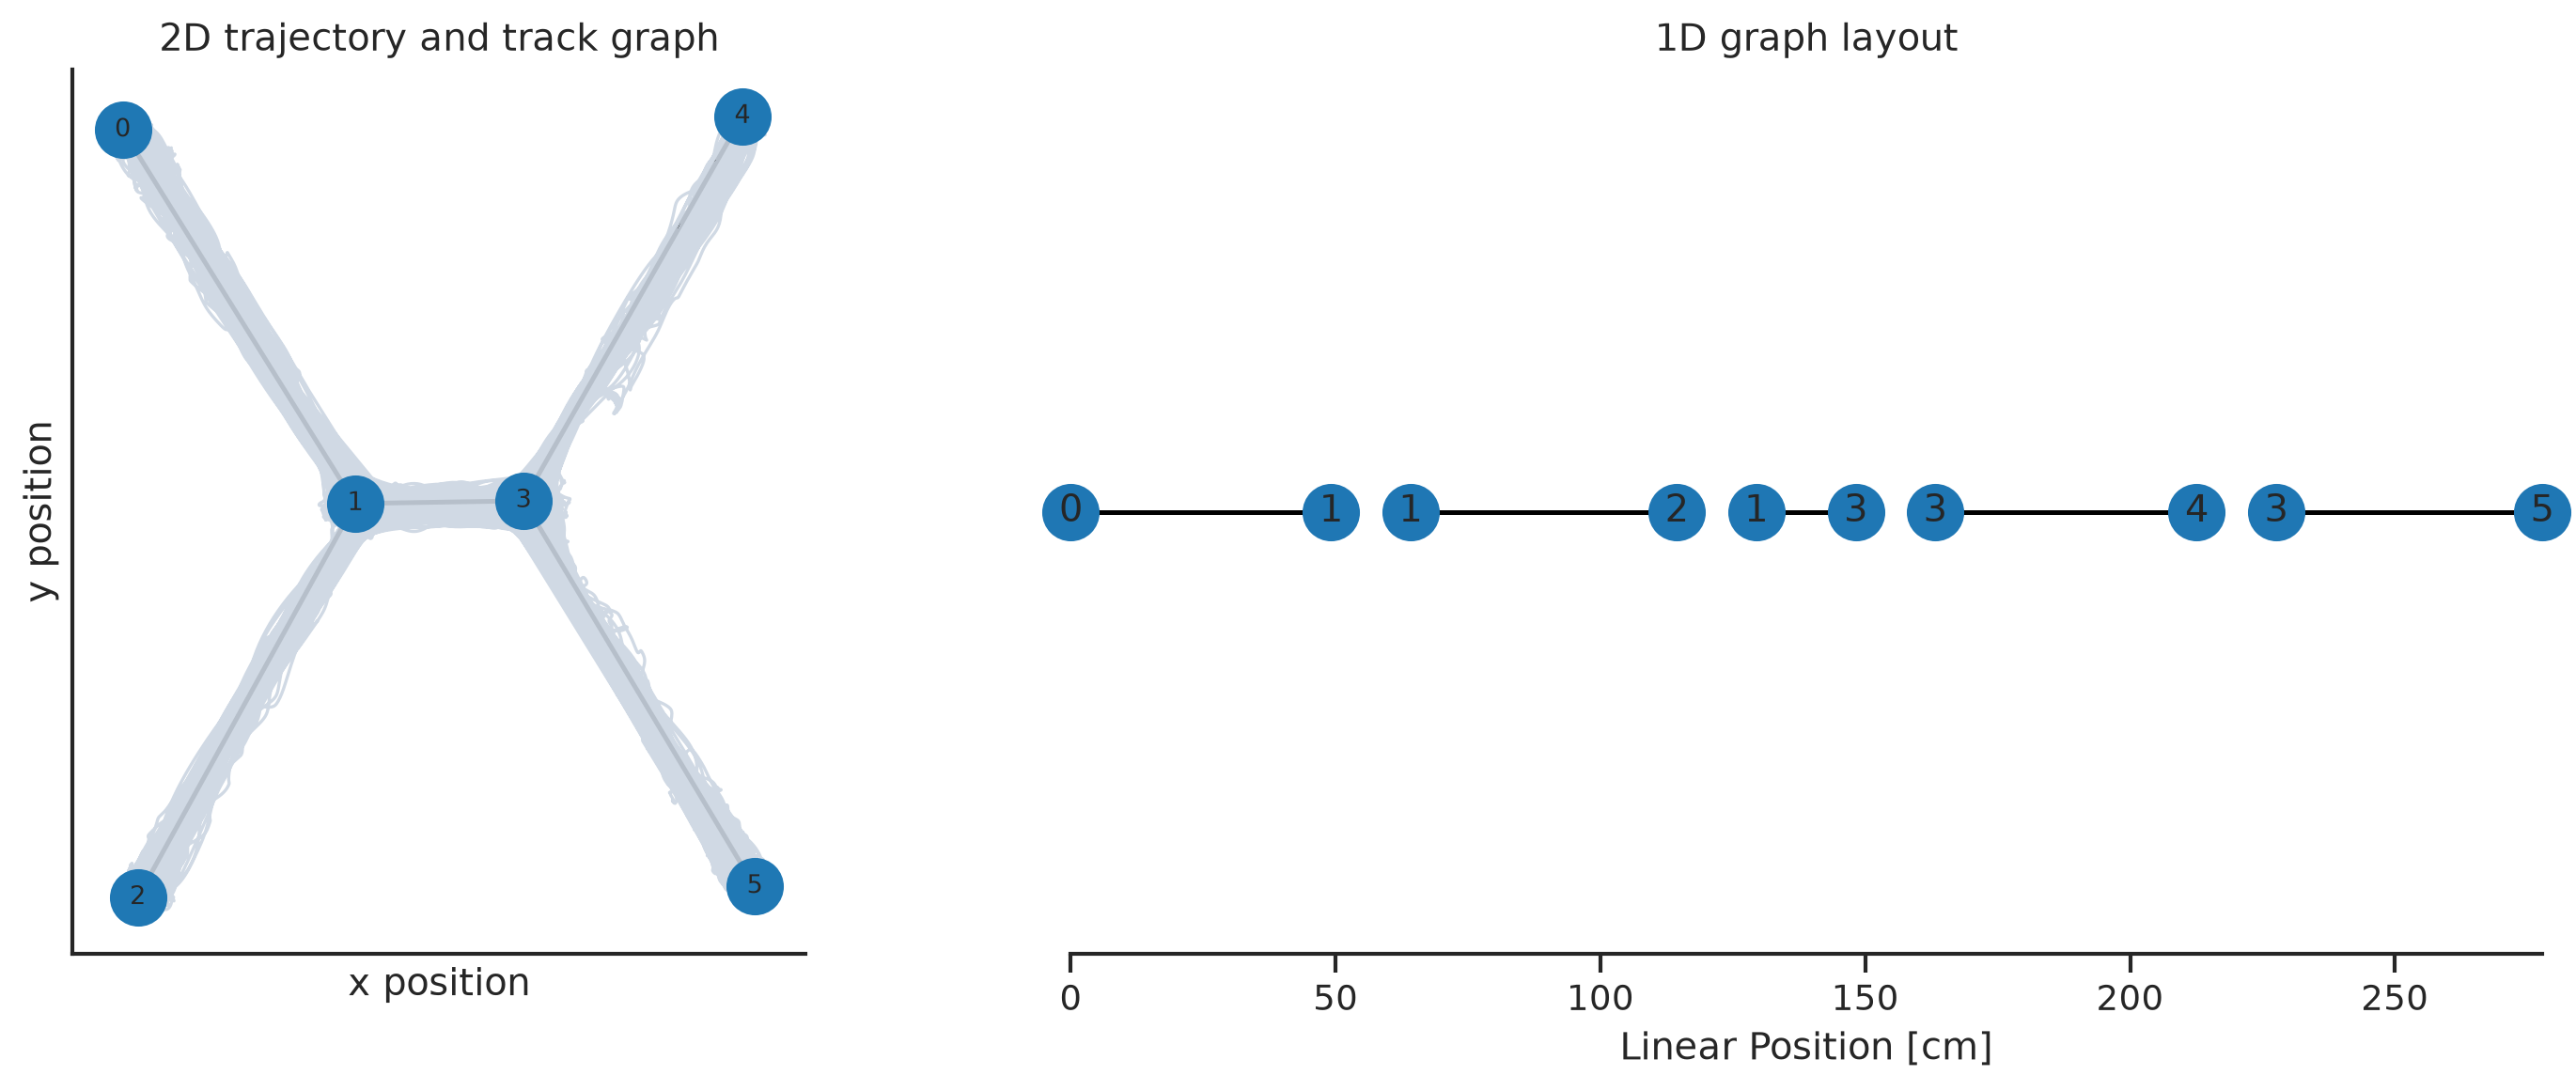

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(position_df['x'], position_df['y'], color=COLORS['gray'], linewidth=1.0, alpha=0.9)
plot_track_graph(track_graph, ax=axes[0])
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel('x position')
axes[0].set_ylabel('y position')
axes[0].set_title('2D trajectory and track graph')

plot_graph_as_1D(track_graph, edge_spacing=15.0, ax=axes[1])
axes[1].set_title('1D graph layout')

plt.tight_layout()
plt.show()


## 11. Inspect a time window on the linearized track

Choose a time window and inspect how the animal moves through linearized position across track segments.


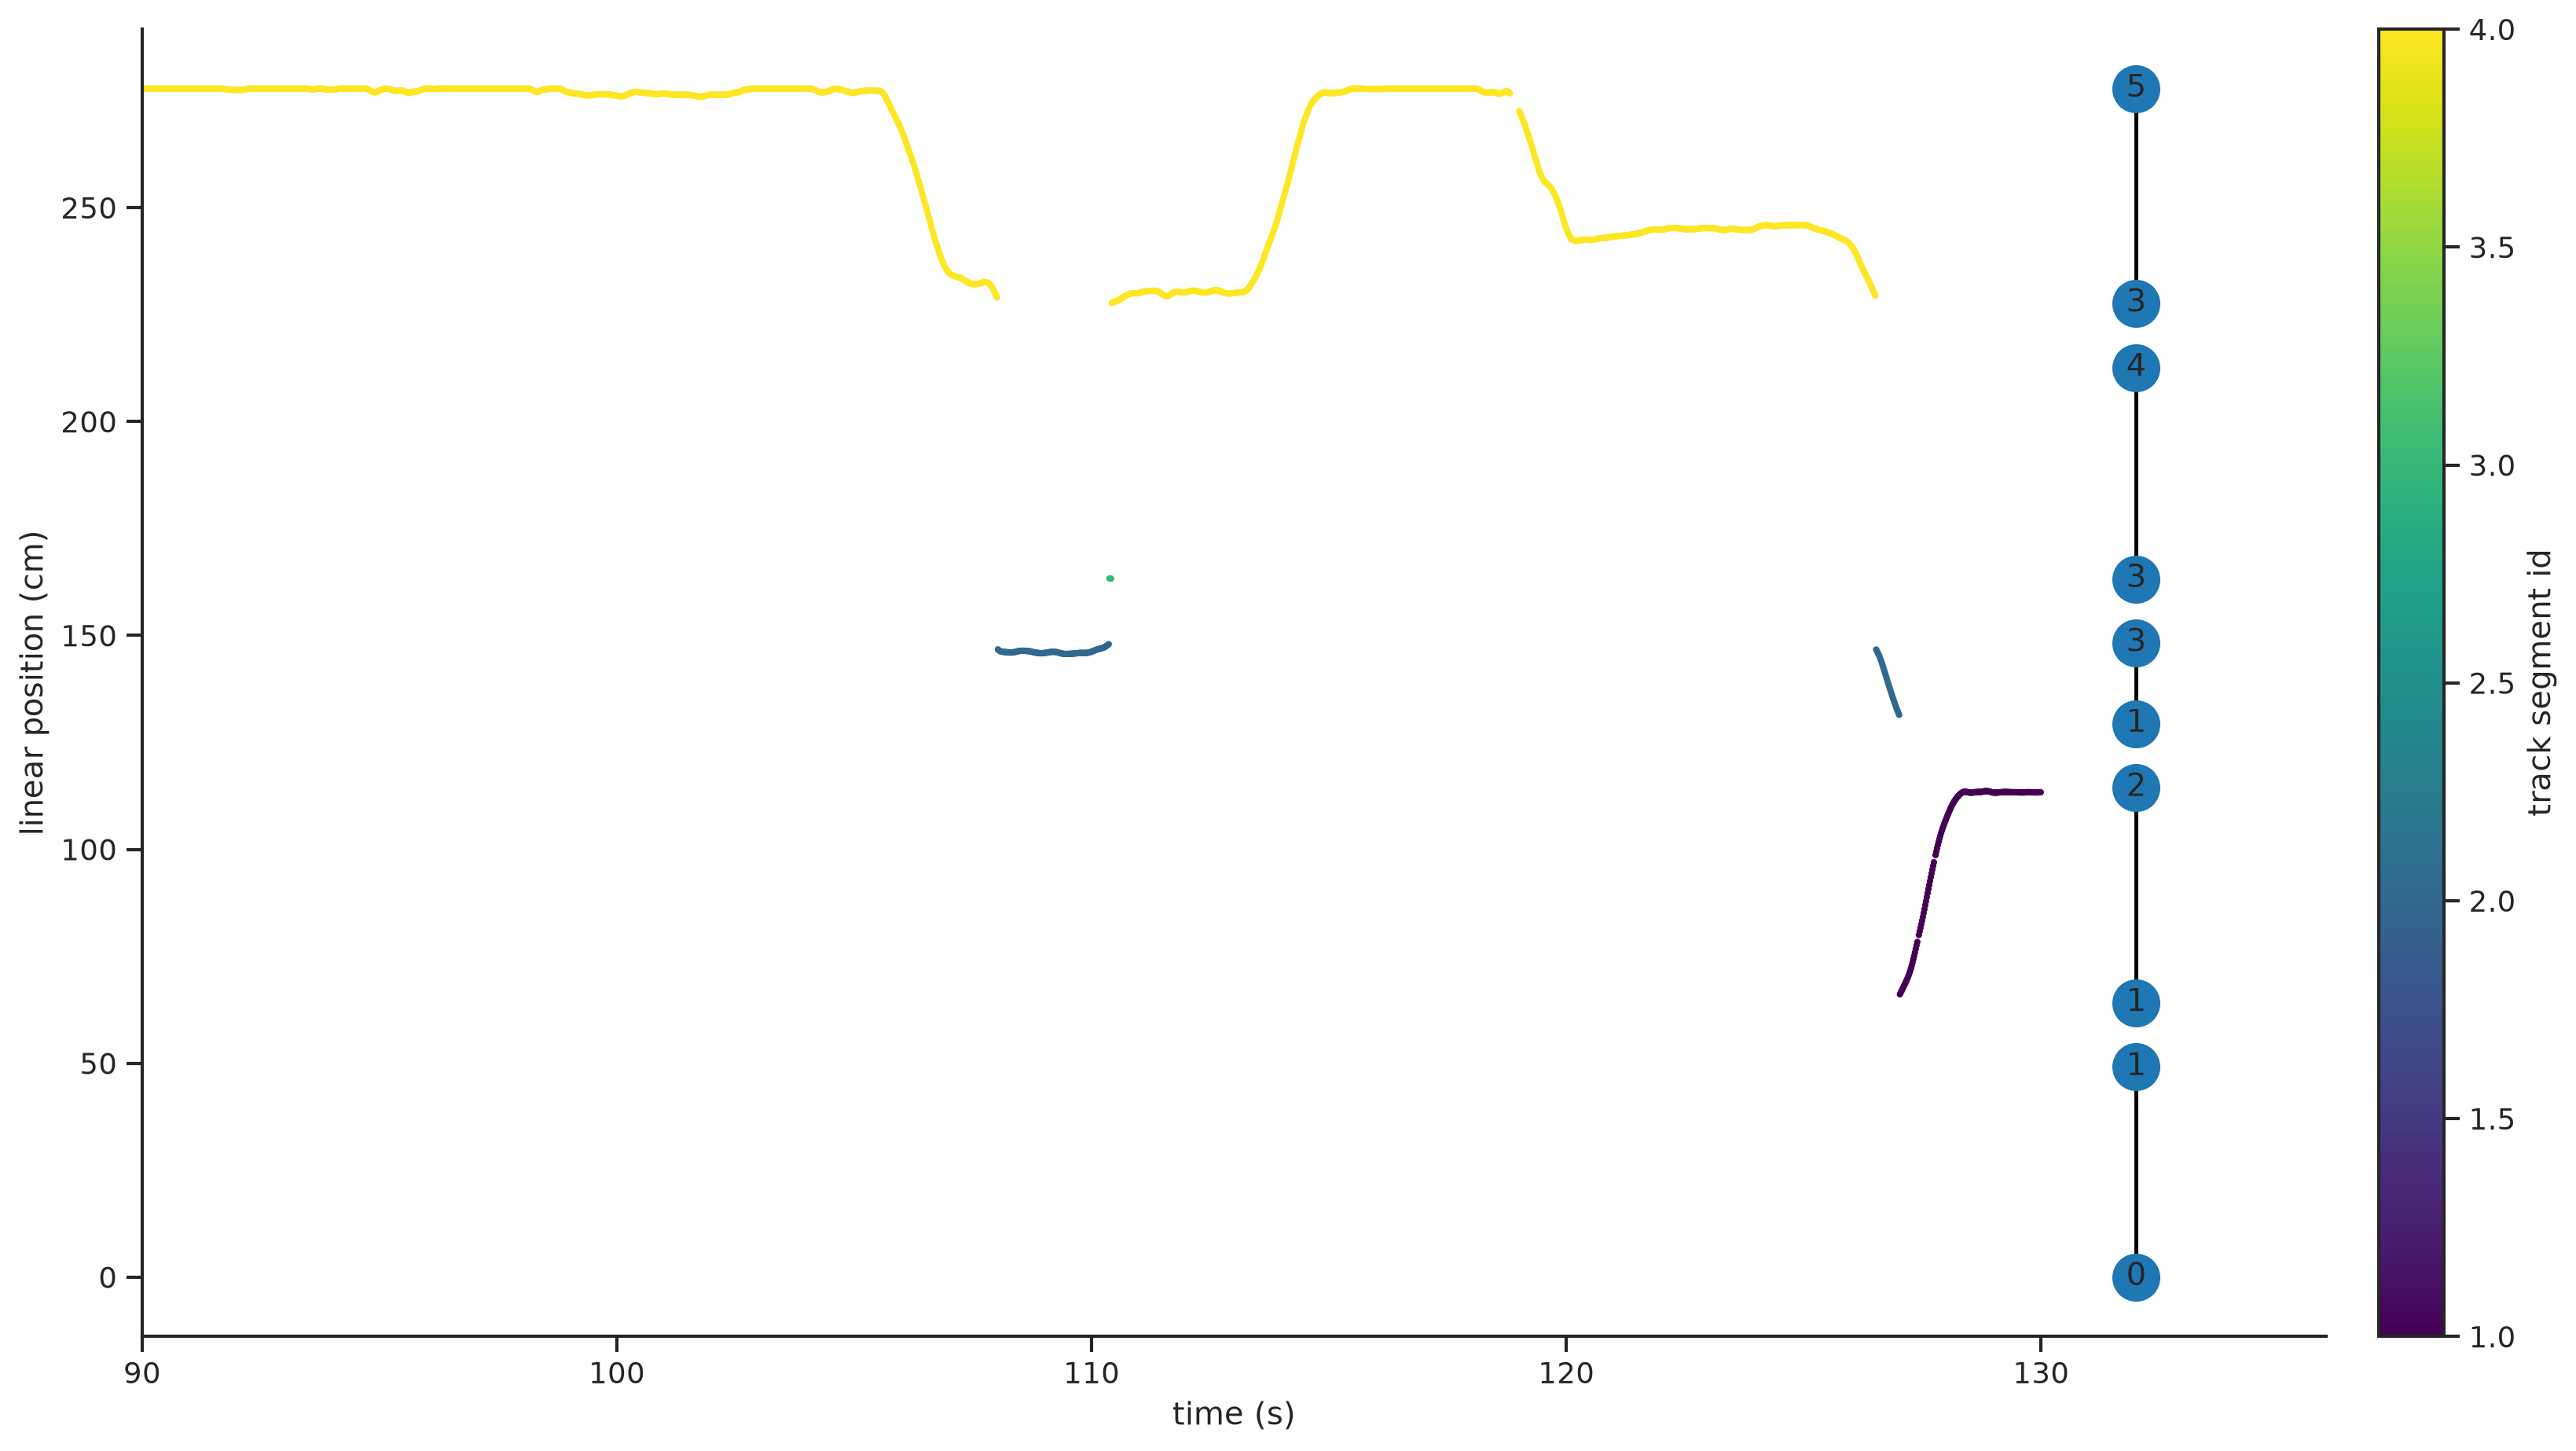

In [18]:
window_start = 90
window_stop = 130

window_df = linear_position_df.query('@window_start <= time <= @window_stop').copy()
if window_df.empty:
    raise ValueError('No samples found in this time window. Choose a different start and stop time.')

fig, ax = plt.subplots(figsize=(18, 9))

scatter = ax.scatter(
    window_df['time'],
    window_df['linear_position'],
    c=window_df['track_segment_id'],
    s=6,
    cmap='viridis',
    linewidths=0,
)

plot_graph_as_1D(
    track_graph,
    edge_spacing=15.0,
    axis='y',
    ax=ax,
    other_axis_start=window_stop + 2.0,
)

plt.colorbar(scatter, ax=ax, pad=0.02, label='track segment id')
ax.set_xlabel('time (s)')
ax.set_ylabel('linear position (cm)')
ax.set_xlim(window_start, window_stop + 6.0)
sns.despine(ax=ax)
plt.show()


## 12. Prepare data for decoding

Now we switch from descriptive rate maps to decoder inputs. In this section we will:

- choose a decoding bin width
- count spikes from each candidate unit in those bins
- assign one true linear position to each bin
- split the session into contiguous cross-validation folds
- use one example fold to inspect training tuning curves
- decode all folds and concatenate the held-out predictions


In [19]:
def make_time_bins(start_time, stop_time, bin_size_s):
    """Create evenly spaced decoding time bins across the session."""
    duration = stop_time - start_time
    n_bins = int(np.floor(duration / bin_size_s))
    bin_edges = start_time + np.arange(n_bins + 1) * bin_size_s
    bin_centers = bin_edges[:-1] + bin_size_s / 2
    return bin_edges, bin_centers


def bin_spike_counts(units_table, unit_ids, candidate_unit_ids, bin_edges):
    """Count spikes from each unit in each decoding bin."""
    spike_count_list = []

    for unit_id in candidate_unit_ids:
        spike_times = np.asarray(fetch_unit_spike_times(units_table, unit_ids, unit_id))
        counts, _ = np.histogram(spike_times, bins=bin_edges)
        spike_count_list.append(counts)

    spike_count_matrix = np.column_stack(spike_count_list)
    return spike_count_matrix


def bin_linear_position(linear_position_df, bin_edges):
    """Assign one linear position to each decoding bin, dropping bins that cross segments."""
    sample_times = linear_position_df['time'].to_numpy()
    sample_positions = linear_position_df['linear_position'].to_numpy()
    sample_segments = linear_position_df['track_segment_id'].to_numpy()

    bin_index = np.digitize(sample_times, bin_edges) - 1
    n_bins = len(bin_edges) - 1

    valid = (
        (bin_index >= 0)
        & (bin_index < n_bins)
        & np.isfinite(sample_positions)
        & pd.notna(sample_segments)
    )

    mean_position = np.full(n_bins, np.nan, dtype=float)
    sample_count = np.zeros(n_bins, dtype=int)
    binned_segment_id = np.full(n_bins, np.nan, dtype=float)
    ambiguous_bin = np.zeros(n_bins, dtype=bool)

    valid_bins = bin_index[valid]
    valid_positions = sample_positions[valid]
    valid_segments = sample_segments[valid]

    for this_bin in range(n_bins):
        in_bin = valid_bins == this_bin
        if not np.any(in_bin):
            continue

        positions_here = valid_positions[in_bin]
        segments_here = valid_segments[in_bin]
        unique_segments = np.unique(segments_here)

        sample_count[this_bin] = len(positions_here)

        if len(unique_segments) != 1:
            ambiguous_bin[this_bin] = True
            continue

        mean_position[this_bin] = positions_here.mean()
        binned_segment_id[this_bin] = unique_segments[0]

    return mean_position, sample_count, binned_segment_id, ambiguous_bin


def split_train_test_by_time(n_bins, train_fraction=0.7, block_size_bins=100):
    """Split bins into interleaved time blocks so train and test both span the session."""
    block_index = np.arange(n_bins) // block_size_bins
    cycle_length = 10
    n_train_blocks = int(np.round(train_fraction * cycle_length))

    train_mask = (block_index % cycle_length) < n_train_blocks
    test_mask = ~train_mask
    return train_mask, test_mask
def compute_1d_tuning_curves_from_binned_data(
    binned_position,
    spike_count_matrix,
    position_edges,
    bin_size_s,
    min_occupancy_s=0.2,
):
    """Estimate one 1D tuning curve per unit from training bins only."""
    valid = np.isfinite(binned_position)
    position_bin_index = np.digitize(binned_position[valid], position_edges) - 1
    n_position_bins = len(position_edges) - 1

    in_range = (position_bin_index >= 0) & (position_bin_index < n_position_bins)
    position_bin_index = position_bin_index[in_range]
    valid_spike_counts = spike_count_matrix[valid][in_range]

    occupancy_s = np.bincount(
        position_bin_index,
        weights=np.full(len(position_bin_index), bin_size_s),
        minlength=n_position_bins,
    )

    tuning_curves = np.full((spike_count_matrix.shape[1], n_position_bins), np.nan, dtype=float)
    occupied = occupancy_s >= min_occupancy_s

    for unit_i in range(spike_count_matrix.shape[1]):
        spike_sums = np.bincount(
            position_bin_index,
            weights=valid_spike_counts[:, unit_i],
            minlength=n_position_bins,
        )
        tuning_curves[unit_i, occupied] = spike_sums[occupied] / occupancy_s[occupied]

    return tuning_curves, occupancy_s


def smooth_1d_tuning_curves(tuning_curves, sigma_bins=1.5):
    """Gaussian-smooth each contiguous valid 1D segment separately."""
    radius = int(np.ceil(4 * sigma_bins))
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel = kernel / kernel.sum()

    smoothed = np.full_like(tuning_curves, np.nan, dtype=float)
    pad_width = len(kernel) // 2

    for unit_i, curve in enumerate(tuning_curves):
        finite = np.isfinite(curve)
        if not np.any(finite):
            continue

        padded = np.pad(finite.astype(int), (1, 1), constant_values=0)
        starts = np.where(np.diff(padded) == 1)[0]
        stops = np.where(np.diff(padded) == -1)[0]

        for start_i, stop_i in zip(starts, stops):
            segment = curve[start_i:stop_i]
            if len(segment) == 0:
                continue

            padded_segment = np.pad(segment, pad_width=pad_width, mode='edge')
            smooth_segment = np.convolve(padded_segment, kernel, mode='valid')
            smoothed[unit_i, start_i:stop_i] = smooth_segment

    return smoothed


def make_structural_position_mask(linear_position_df, position_centers):
    """Mark position bins that lie on a real track segment, using track_segment_id."""
    valid_rows = linear_position_df[['linear_position', 'track_segment_id']].dropna().copy()
    structural_mask = np.zeros(len(position_centers), dtype=bool)

    for _, segment_df in valid_rows.groupby('track_segment_id'):
        segment_min = segment_df['linear_position'].min()
        segment_max = segment_df['linear_position'].max()
        on_segment = (position_centers >= segment_min) & (position_centers <= segment_max)
        structural_mask |= on_segment

    return structural_mask


In [42]:
bin_size_s = 0.25

session_start = linear_position_df['time'].min()
session_stop = linear_position_df['time'].max()
decode_bin_edges, decode_bin_centers = make_time_bins(session_start, session_stop, bin_size_s)

candidate_unit_ids = candidate_units.index.to_numpy()
spike_count_matrix = bin_spike_counts(units_table, unit_ids, candidate_unit_ids, decode_bin_edges)
(
    binned_linear_position,
    binned_position_sample_count,
    binned_track_segment_id,
    ambiguous_position_bin,
) = bin_linear_position(linear_position_df, decode_bin_edges)

decode_df = pd.DataFrame({
    'time': decode_bin_centers,
    'true_linear_position': binned_linear_position,
    'track_segment_id': binned_track_segment_id,
    'n_position_samples': binned_position_sample_count,
    'position_bin_is_ambiguous': ambiguous_position_bin,
})

print(f'Decoding bin width: {bin_size_s:.3f} s')
print(f'Number of decoding bins: {len(decode_df)}')
print(f'Spike-count matrix shape: {spike_count_matrix.shape}')
print(f'Ambiguous position bins dropped: {ambiguous_position_bin.sum()}')
display(decode_df.head())


Decoding bin width: 0.250 s
Number of decoding bins: 7721
Spike-count matrix shape: (7721, 53)
Ambiguous position bins dropped: 588


,time,true_linear_position,track_segment_id,n_position_samples,position_bin_is_ambiguous
0,4.56663,113.315177,1.0,15,False
1,4.81663,113.338554,1.0,15,False
2,5.06663,113.337876,1.0,15,False
3,5.31663,113.302926,1.0,15,False
4,5.56663,113.332184,1.0,15,False


In [43]:
from sklearn.model_selection import KFold

n_splits = 5
valid_position_mask = (
    decode_df['true_linear_position'].notna()
    & ~decode_df['position_bin_is_ambiguous']
)
valid_bin_indices = np.flatnonzero(valid_position_mask.to_numpy())

cv = KFold(n_splits=n_splits, shuffle=False)
folds = list(cv.split(valid_bin_indices))

# Use fold 1 as a concrete example for the training tuning-curve section below.
example_train_ind, example_test_ind = folds[0]
example_train_bins = valid_bin_indices[example_train_ind]
example_test_bins = valid_bin_indices[example_test_ind]

example_train_mask = np.zeros(len(decode_df), dtype=bool)
example_test_mask = np.zeros(len(decode_df), dtype=bool)
example_train_mask[example_train_bins] = True
example_test_mask[example_test_bins] = True

decode_df['is_valid_for_decoding'] = valid_position_mask
decode_df['is_example_train'] = example_train_mask
decode_df['is_example_test'] = example_test_mask

print(f'Cross-validation folds: {n_splits}')
print(f'Valid bins available for decoding: {len(valid_bin_indices)} / {len(decode_df)}')
print(f'Example fold training bins: {example_train_mask.sum()}')
print(f'Example fold test bins: {example_test_mask.sum()}')
display(decode_df.loc[valid_position_mask].head(12))


Cross-validation folds: 5
Valid bins available for decoding: 7121 / 7721
Example fold training bins: 5696
Example fold test bins: 1425


,time,true_linear_position,track_segment_id,n_position_samples,position_bin_is_ambiguous,is_valid_for_decoding,is_example_train,is_example_test
0,4.56663,113.315177,1.0,15,False,True,False,True
1,4.81663,113.338554,1.0,15,False,True,False,True
2,5.06663,113.337876,1.0,15,False,True,False,True
3,5.31663,113.302926,1.0,15,False,True,False,True
4,5.56663,113.332184,1.0,15,False,True,False,True
5,5.81663,113.336632,1.0,15,False,True,False,True
6,6.06663,113.320998,1.0,15,False,True,False,True
7,6.31663,112.812077,1.0,15,False,True,False,True
8,6.56663,112.613562,1.0,15,False,True,False,True
9,6.81663,112.704560,1.0,15,False,True,False,True


In [44]:
position_bin_size_cm = 2.5
min_training_occupancy_s = 0.2
decoder_tuning_smoothing_sigma = 1.5

position_min = np.nanmin(linear_position_df['linear_position'])
position_max = np.nanmax(linear_position_df['linear_position'])
decode_position_edges = np.arange(position_min, position_max + position_bin_size_cm, position_bin_size_cm)
decode_position_centers = decode_position_edges[:-1] + position_bin_size_cm / 2

training_tuning_curves, training_occupancy_s = compute_1d_tuning_curves_from_binned_data(
    binned_position=decode_df.loc[example_train_mask, 'true_linear_position'].to_numpy(),
    spike_count_matrix=spike_count_matrix[example_train_mask],
    position_edges=decode_position_edges,
    bin_size_s=bin_size_s,
    min_occupancy_s=min_training_occupancy_s,
)

structural_valid_bins = make_structural_position_mask(
    linear_position_df,
    decode_position_centers,
)

training_tuning_curves[:, ~structural_valid_bins] = np.nan

smoothed_training_tuning_curves = smooth_1d_tuning_curves(
    training_tuning_curves,
    sigma_bins=decoder_tuning_smoothing_sigma,
)
smoothed_training_tuning_curves[:, ~structural_valid_bins] = np.nan

print(f'Position bin size for decoder tuning curves: {position_bin_size_cm:.1f} cm')
print(f'Tuning-curve array shape: {training_tuning_curves.shape}')
print(f'Decoder tuning-curve smoothing sigma: {decoder_tuning_smoothing_sigma:.1f} bins')
print(f'Structural position bins on the graph: {structural_valid_bins.sum()} / {len(structural_valid_bins)}')
print('Example fold used for this plot: fold 1')
print(f'Position bins with enough training occupancy: {(training_occupancy_s >= min_training_occupancy_s).sum()}')


Position bin size for decoder tuning curves: 2.5 cm
Tuning-curve array shape: (53, 112)
Plot smoothing sigma: 1.5 bins
Structural position bins on the graph: 87 / 112
Example fold used for this plot: fold 1
Position bins with enough training occupancy: 91


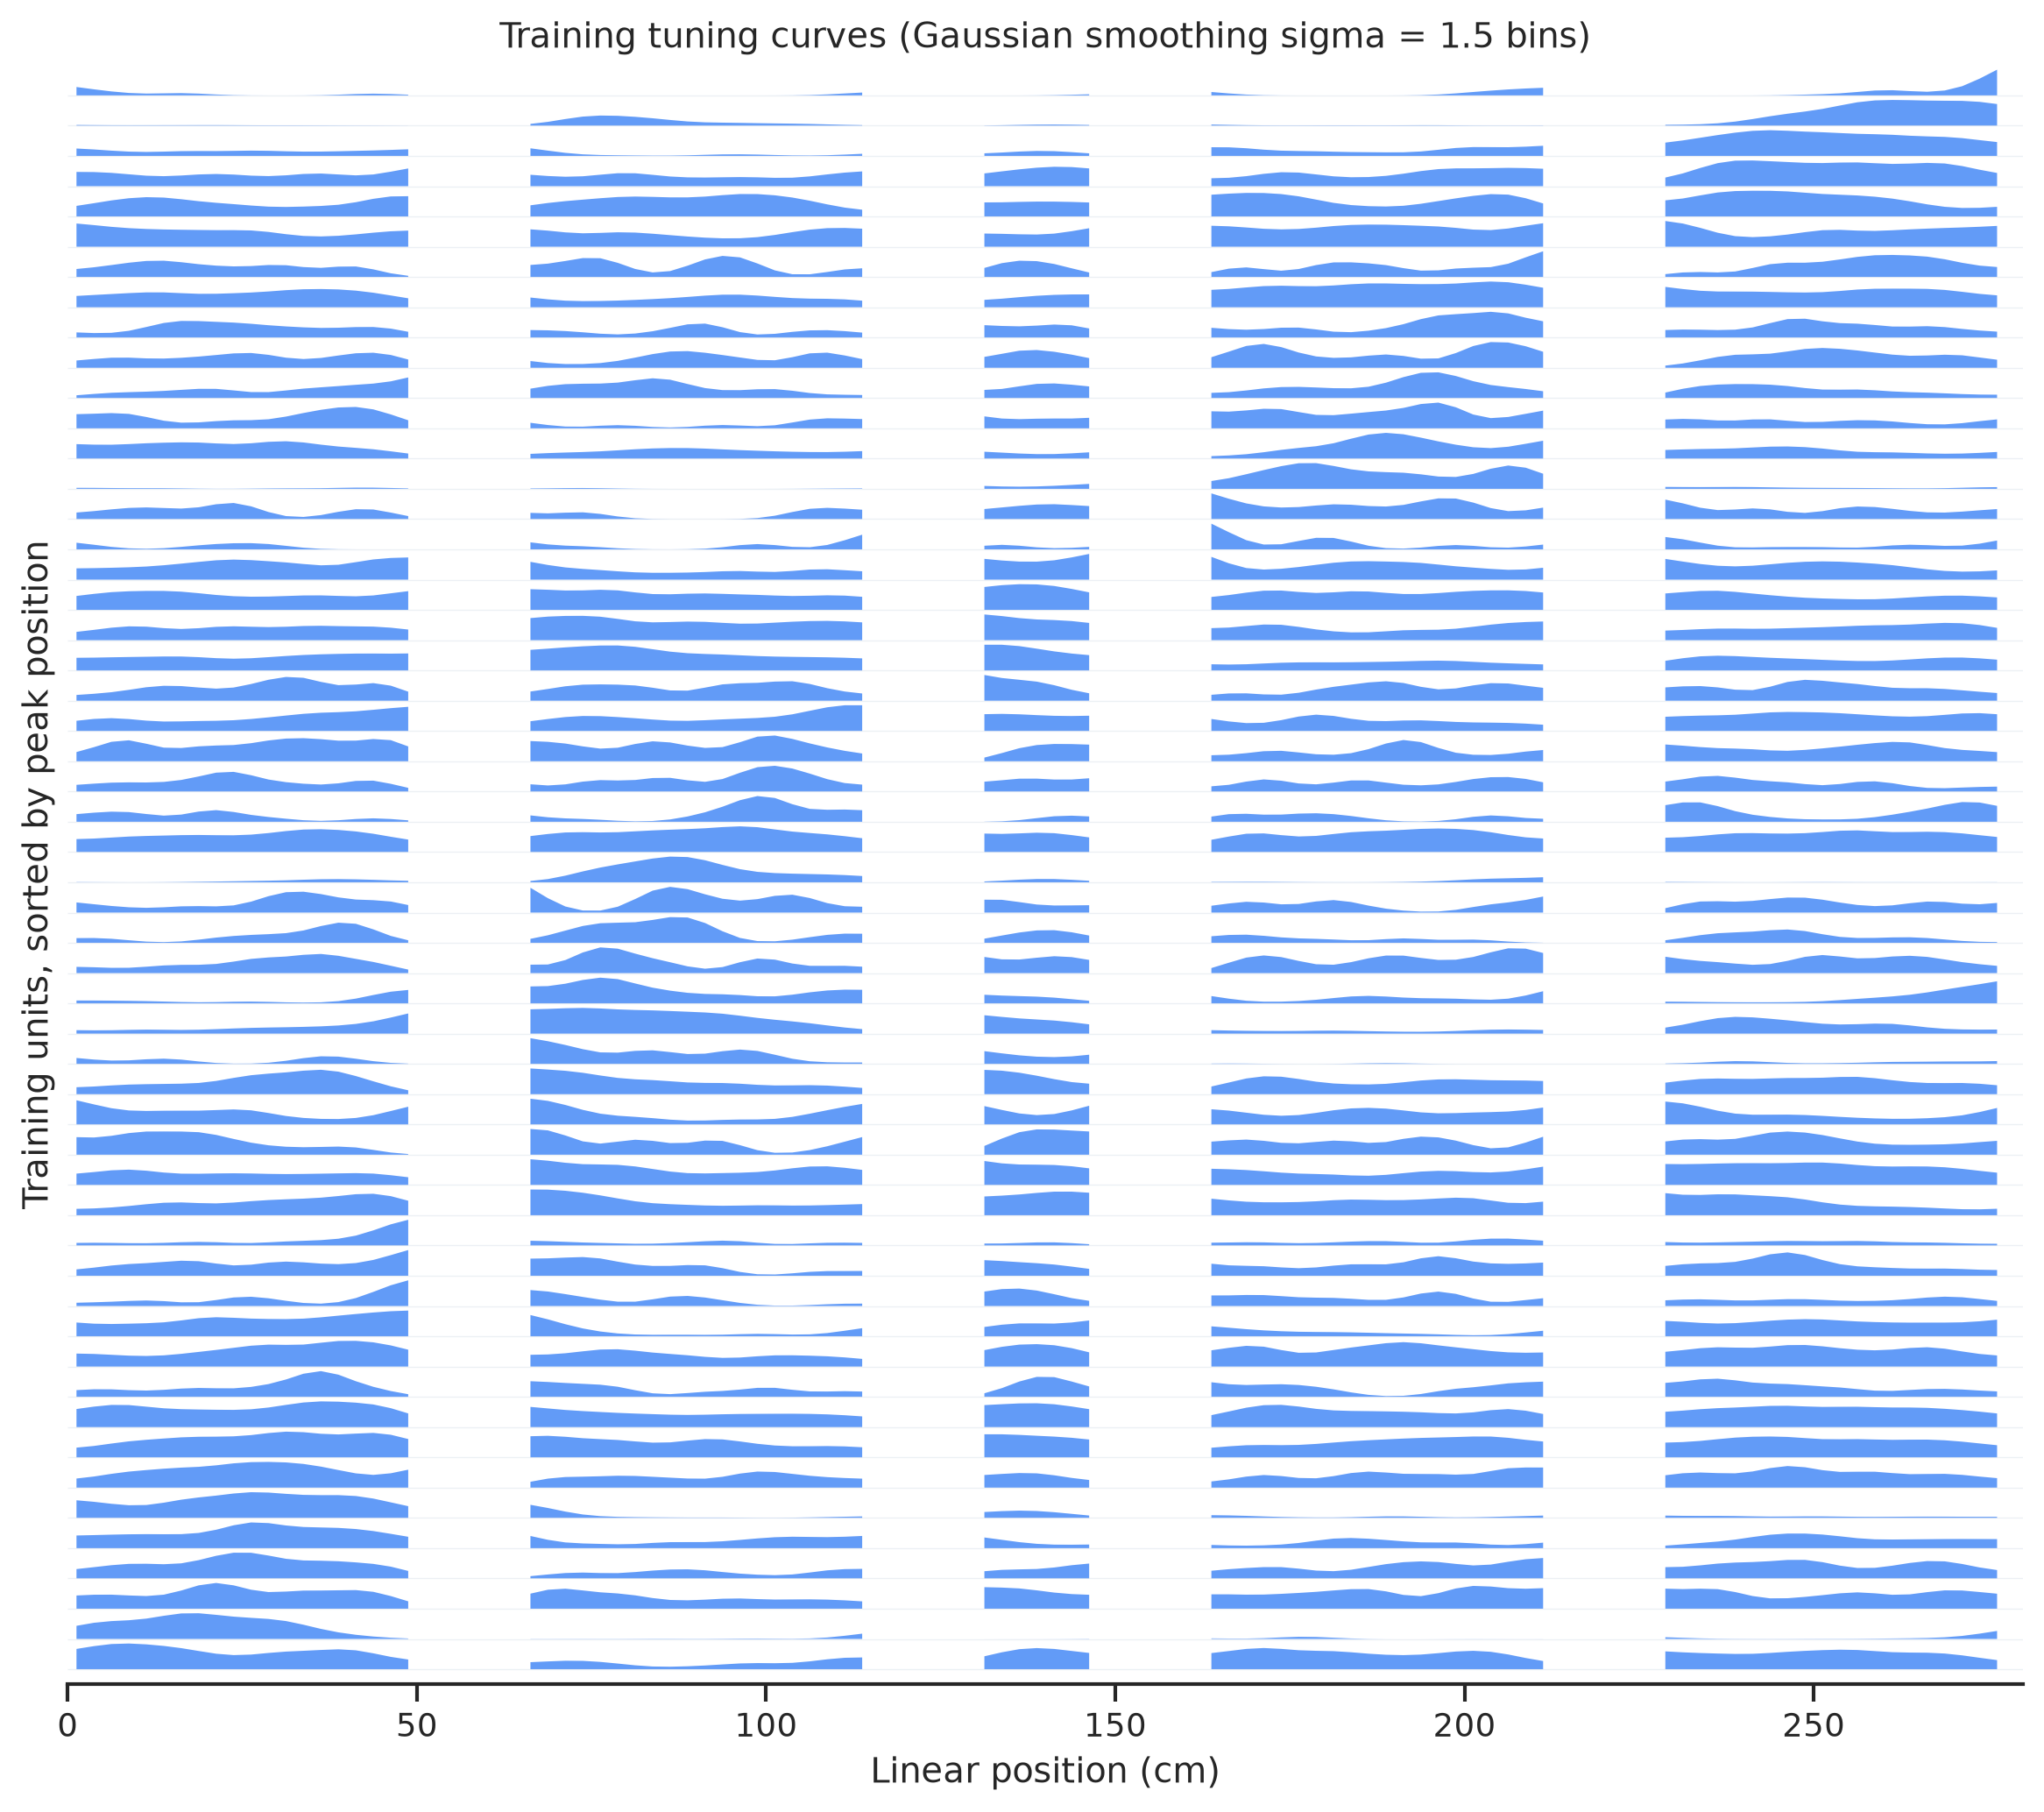

In [45]:
peak_positions_training = np.full(len(candidate_unit_ids), np.nan, dtype=float)

for unit_i, tuning_curve in enumerate(smoothed_training_tuning_curves):
    finite = np.isfinite(tuning_curve)
    if not np.any(finite):
        continue

    curve_max = np.nanmax(tuning_curve)
    if curve_max <= 0:
        continue

    peak_positions_training[unit_i] = decode_position_centers[np.nanargmax(tuning_curve)]

sort_order_training = np.argsort(np.nan_to_num(peak_positions_training, nan=np.inf))
sorted_training_unit_ids = candidate_unit_ids[sort_order_training]
sorted_training_tuning_curves = smoothed_training_tuning_curves[sort_order_training]

fig_height = max(10, 0.18 * len(sorted_training_unit_ids))
fig, ax = plt.subplots(figsize=(12, fig_height))

row_step = 1.0
amplitude_scale = 0.85

for row_i, tuning_curve in enumerate(sorted_training_tuning_curves):
    baseline = row_i * row_step
    ax.hlines(baseline, decode_position_edges[0], decode_position_edges[-1], color=COLORS['gray'], linewidth=0.4, alpha=0.35)

    finite = np.isfinite(tuning_curve)
    if not np.any(finite):
        continue

    curve_max = np.nanmax(tuning_curve)
    if curve_max <= 0:
        continue

    scaled_curve = baseline + amplitude_scale * (tuning_curve / curve_max)
    ax.fill_between(
        decode_position_centers,
        baseline,
        scaled_curve,
        where=finite,
        color=COLORS['blue'],
        alpha=0.8,
        linewidth=0,
    )

ax.set_xlim(decode_position_edges[0], decode_position_edges[-1])
ax.set_ylim(-0.5, len(sorted_training_unit_ids) * row_step)
ax.set_xlabel('Linear position (cm)')
ax.set_ylabel('Training units, sorted by peak position')
ax.set_title(f'Training tuning curves (Gaussian smoothing sigma = {decoder_tuning_smoothing_sigma:.1f} bins)')
ax.set_yticks([])
sns.despine(ax=ax, left=True)
plt.show()


## 13. Decode position from population spikes

Now we use the training tuning curves to predict position in held-out time bins.

For each time bin, we know how many spikes each unit fired. The decoder asks:

- if the animal were at position `x`, how likely would this spike pattern be?
- after checking all candidate positions, which one looks most likely?

We will use a standard Poisson model. If unit `i` has tuning curve `f_i(x)` in spikes/s and the decoding bin has width `Δt`, then the expected spike count is:

$$\lambda_i(x) = f_i(x)\Delta t$$

For an observed spike count `n_i`, the Poisson likelihood is:

$$P(n_i\mid x) = \frac{\lambda_i(x)^{n_i}e^{-\lambda_i(x)}}{n_i!}$$

Assuming the units are conditionally independent given position, we multiply those likelihoods across units. We will start with a uniform prior over position bins, so the most likely position is the one with the largest posterior.

### 13.1 Set up contiguous cross-validation folds

We now switch from a single train/test split to contiguous cross-validation, like the `pose_analysis` notebook.

We only decode bins that:

- have a valid true linear position
- are not ambiguous across track segments

Then we split those valid bins into `5` contiguous folds.

For each fold:

- train on the other 4 folds
- predict posterior on the held-out fold
- store those held-out predictions

After all folds are done, every valid time bin has a held-out posterior.

In [46]:
n_decode_bins = len(decode_df)
n_position_bins = len(decode_position_centers)

posterior_full = np.full((n_decode_bins, n_position_bins), np.nan, dtype=float)
decoded_linear_position_full = np.full(n_decode_bins, np.nan, dtype=float)
posterior_mean_position_full = np.full(n_decode_bins, np.nan, dtype=float)
posterior_peak_probability_full = np.full(n_decode_bins, np.nan, dtype=float)
fold_index_full = np.full(n_decode_bins, np.nan, dtype=float)

print(f'Valid bins available for decoding: {len(valid_bin_indices)}')
print(f'Number of folds: {n_splits}')
print(f'Posterior storage shape: {posterior_full.shape}')
display(decode_df.loc[valid_position_mask].head())


Valid bins available for decoding: 7121
Number of folds: 5
Posterior storage shape: (7721, 112)


,time,true_linear_position,track_segment_id,n_position_samples,position_bin_is_ambiguous,is_valid_for_decoding,is_example_train,is_example_test
0,4.56663,113.315177,1.0,15,False,True,False,True
1,4.81663,113.338554,1.0,15,False,True,False,True
2,5.06663,113.337876,1.0,15,False,True,False,True
3,5.31663,113.302926,1.0,15,False,True,False,True
4,5.56663,113.332184,1.0,15,False,True,False,True


### 13.2 Compute the posterior over position

Next we turn the tuning curves into an encoding model.

Step by step:

- the smoothed tuning curve gives an expected firing rate at each position bin
- multiplying by the decoding bin width converts rate into expected spike count
- we score how well each candidate position explains the observed spike counts
- we normalize those scores into a posterior distribution over position

We will work in log space because multiplying many small probabilities directly is numerically unstable.

In [47]:
def compute_poisson_log_likelihood(spike_count_matrix, expected_spike_count_matrix):
    """Score each candidate position using an independent Poisson model."""
    safe_expected = np.clip(expected_spike_count_matrix, 1e-12, None)
    log_expected = np.log(safe_expected)

    # The log(n!) term is omitted because it does not depend on position.
    log_likelihood = spike_count_matrix @ log_expected - safe_expected.sum(axis=0)
    return log_likelihood


def log_likelihood_to_posterior(log_likelihood, log_prior=None):
    """Convert log-likelihoods into normalized posterior probabilities."""
    if log_prior is None:
        n_positions = log_likelihood.shape[1]
        log_prior = np.full(n_positions, -np.log(n_positions), dtype=float)

    log_posterior = log_likelihood + log_prior
    log_posterior = log_posterior - np.max(log_posterior, axis=1, keepdims=True)

    posterior = np.exp(log_posterior)
    posterior = posterior / posterior.sum(axis=1, keepdims=True)
    return posterior


### 13.3 Extract one decoded position per bin

We now loop over the folds.

In each fold we:

- build tuning curves from the training folds only
- smooth those tuning curves
- predict posterior on the held-out fold only
- place those held-out predictions back into their original time bins

Two simple summaries are useful:

- the maximum a posteriori (MAP) estimate: the position bin with the largest posterior probability
- the posterior mean: the probability-weighted average position

The MAP is easiest to interpret when the posterior has one clear peak. The posterior mean can look smoother, but it can be misleading on a branched track if probability is split across arms.


In [48]:
for fold_ind, (train_ind, test_ind) in enumerate(folds, start=1):
    train_bins = valid_bin_indices[train_ind]
    test_bins = valid_bin_indices[test_ind]

    fold_train_mask = np.zeros(len(decode_df), dtype=bool)
    fold_train_mask[train_bins] = True

    fold_training_tuning_curves, fold_training_occupancy_s = compute_1d_tuning_curves_from_binned_data(
        binned_position=decode_df.loc[fold_train_mask, 'true_linear_position'].to_numpy(),
        spike_count_matrix=spike_count_matrix[fold_train_mask],
        position_edges=decode_position_edges,
        bin_size_s=bin_size_s,
        min_occupancy_s=min_training_occupancy_s,
    )

    fold_training_tuning_curves[:, ~structural_valid_bins] = np.nan
    fold_smoothed_tuning_curves = smooth_1d_tuning_curves(
        fold_training_tuning_curves,
        sigma_bins=decoder_tuning_smoothing_sigma,
    )
    fold_smoothed_tuning_curves[:, ~structural_valid_bins] = np.nan

    fold_position_mask = structural_valid_bins & (fold_training_occupancy_s >= min_training_occupancy_s)
    fold_candidate_positions = decode_position_centers[fold_position_mask]
    fold_expected_spike_count_matrix = fold_smoothed_tuning_curves[:, fold_position_mask] * bin_size_s

    fold_test_spike_count_matrix = spike_count_matrix[test_bins]
    fold_log_likelihood = compute_poisson_log_likelihood(
        spike_count_matrix=fold_test_spike_count_matrix,
        expected_spike_count_matrix=fold_expected_spike_count_matrix,
    )
    fold_posterior_compact = log_likelihood_to_posterior(fold_log_likelihood)

    posterior_full[np.ix_(test_bins, fold_position_mask)] = fold_posterior_compact

    fold_decoded_position_index = np.argmax(fold_posterior_compact, axis=1)
    decoded_linear_position_full[test_bins] = fold_candidate_positions[fold_decoded_position_index]
    posterior_mean_position_full[test_bins] = fold_posterior_compact @ fold_candidate_positions
    posterior_peak_probability_full[test_bins] = fold_posterior_compact[
        np.arange(len(fold_decoded_position_index)),
        fold_decoded_position_index,
    ]
    fold_index_full[test_bins] = fold_ind

decode_results_df = decode_df.loc[valid_position_mask, ['time', 'true_linear_position']].copy()
decode_results_df['decoded_linear_position'] = decoded_linear_position_full[valid_position_mask]
decode_results_df['posterior_mean_position'] = posterior_mean_position_full[valid_position_mask]
decode_results_df['absolute_error_cm'] = np.abs(
    decode_results_df['decoded_linear_position'] - decode_results_df['true_linear_position']
)
decode_results_df['posterior_mean_absolute_error_cm'] = np.abs(
    decode_results_df['posterior_mean_position'] - decode_results_df['true_linear_position']
)
decode_results_df['posterior_peak_probability'] = posterior_peak_probability_full[valid_position_mask]
decode_results_df['fold_index'] = fold_index_full[valid_position_mask].astype(int)

test_times = decode_results_df['time'].to_numpy()
test_true_positions = decode_results_df['true_linear_position'].to_numpy()
posterior = posterior_full[valid_position_mask]
decoded_linear_position = decode_results_df['decoded_linear_position'].to_numpy()
posterior_mean_position = decode_results_df['posterior_mean_position'].to_numpy()

print(f'Cross-validated posterior shape: {posterior.shape}')
print(f'Decoded bins across all folds: {len(decode_results_df)}')
print(f"Median MAP absolute error: {np.median(decode_results_df['absolute_error_cm']):.2f} cm")
print(f"Median posterior-mean absolute error: {np.median(decode_results_df['posterior_mean_absolute_error_cm']):.2f} cm")
display(decode_results_df.head())


Cross-validated posterior shape: (7121, 112)
Decoded bins across all folds: 7121
Median absolute decoding error: 25.32 cm


,time,true_linear_position,decoded_linear_position,absolute_error_cm,posterior_peak_probability,fold_index
0,4.56663,113.315177,103.75,9.565177,0.191280,1
1,4.81663,113.338554,103.75,9.588554,0.321247,1
2,5.06663,113.337876,103.75,9.587876,0.319203,1
3,5.31663,113.302926,238.75,125.447074,0.138003,1
4,5.56663,113.332184,163.75,50.417816,0.246464,1


### 13.4 Compare true and decoded position in a chosen time window

Now choose a time window and look at the full posterior over position.

- the background image shows posterior probability across position bins
- darker regions mean the decoder assigned higher probability there
- the magenta trace shows the animal's true linear position
- the orange overlay can show either the MAP estimate or the posterior mean

This lets you see the decoded summary while still checking whether the full posterior was uncertain, multimodal, or confidently wrong.


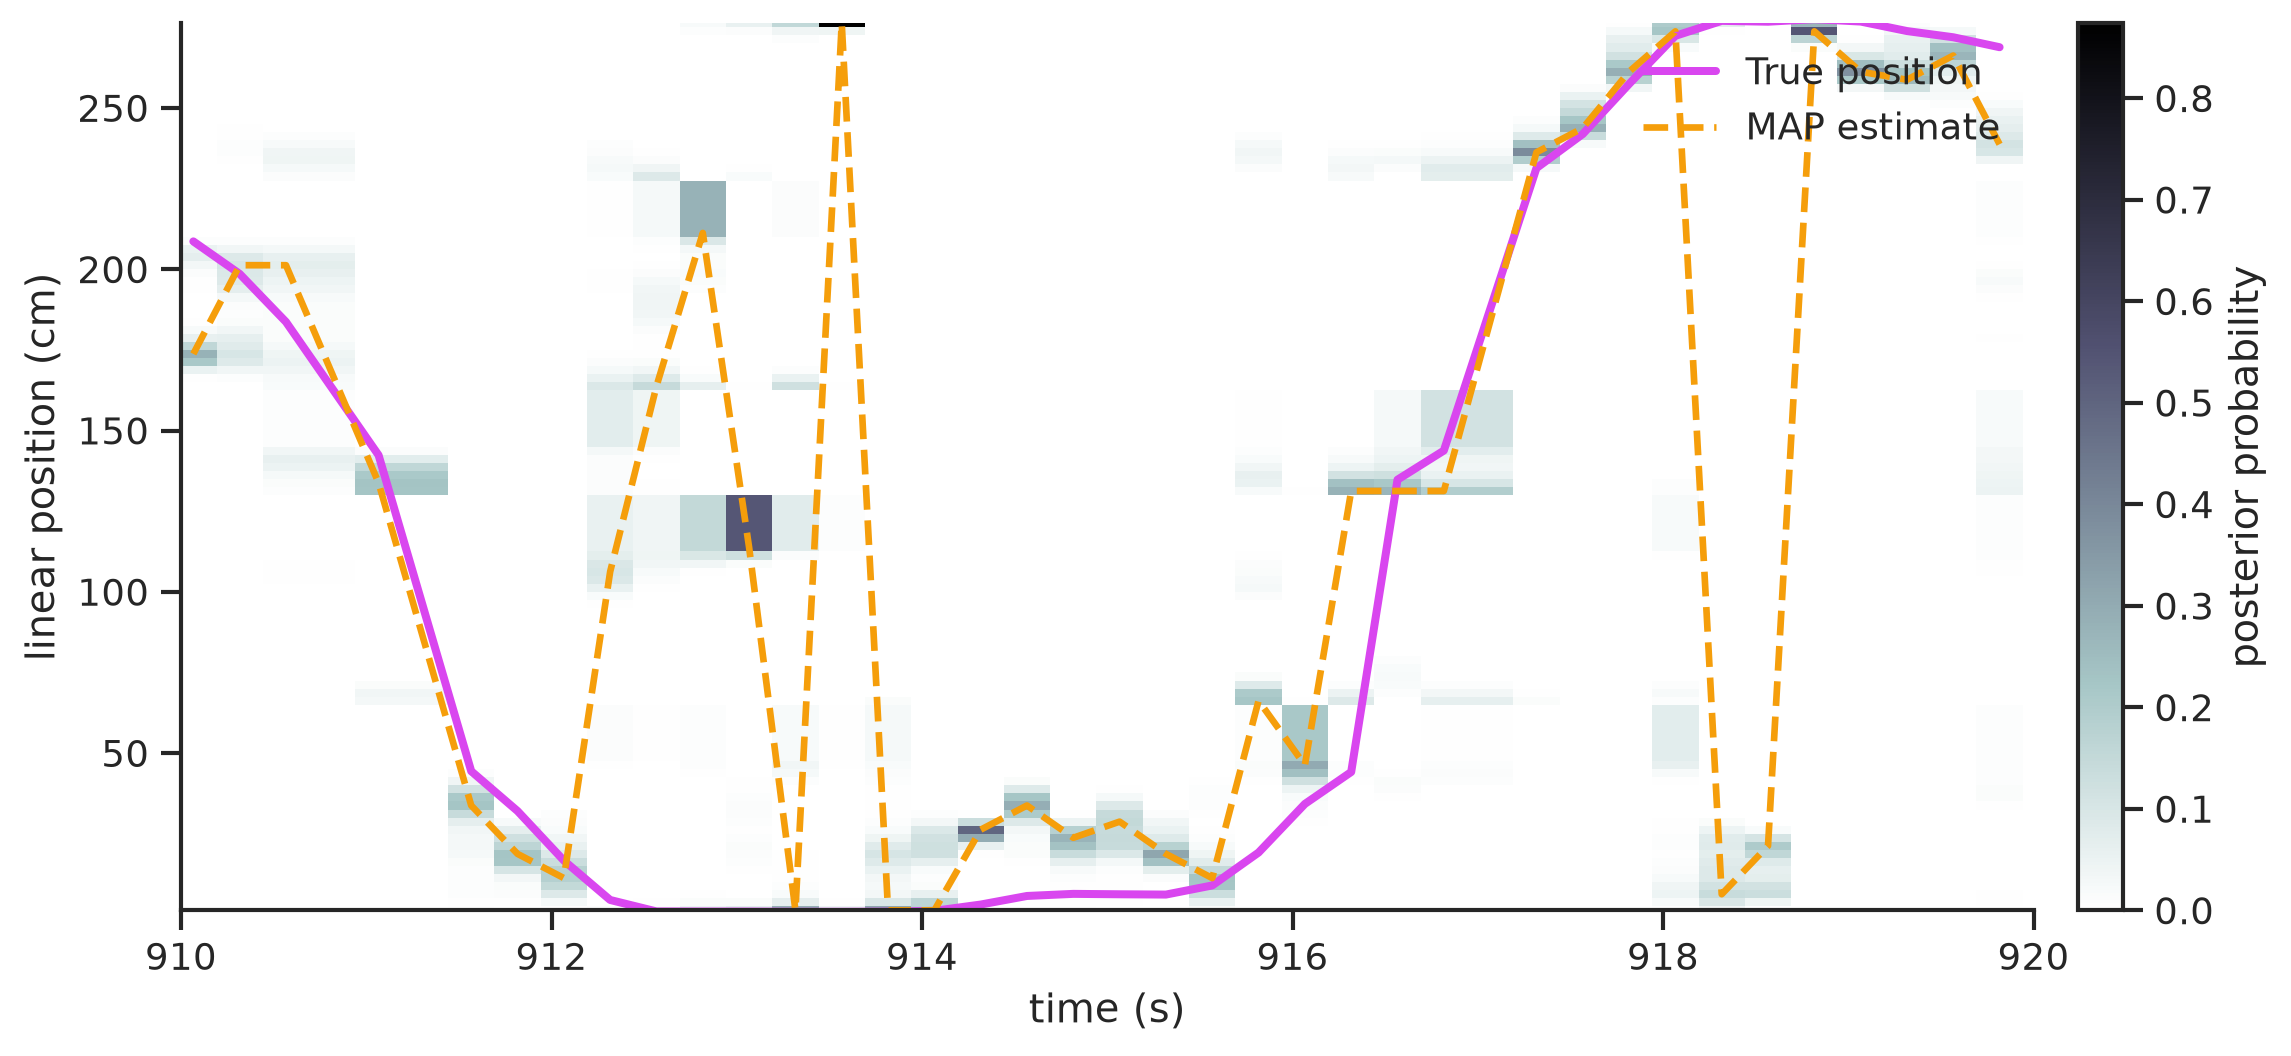

In [51]:
decode_window_start = 910
decode_window_stop = 920
decoded_estimate_to_plot = 'map'  # Choose 'map' or 'posterior_mean'.

window_decode_mask = (test_times >= decode_window_start) & (test_times <= decode_window_stop)
if not np.any(window_decode_mask):
    raise ValueError('No decoded bins found in this time window. Choose a different start and stop time.')

window_times = test_times[window_decode_mask]
window_true_positions = test_true_positions[window_decode_mask]
window_map_positions = decoded_linear_position[window_decode_mask]
window_posterior_mean_positions = posterior_mean_position[window_decode_mask]
window_posterior = posterior[window_decode_mask]

window_position_mask = ~np.all(np.isnan(window_posterior), axis=0)
plot_positions = decode_position_centers[window_position_mask]
plot_posterior = window_posterior[:, window_position_mask]

if len(plot_positions) == 0:
    raise ValueError('No posterior values are available in this window. Choose a different time range.')

if decoded_estimate_to_plot == 'map':
    window_decoded_positions = window_map_positions
    decoded_label = 'MAP estimate'
elif decoded_estimate_to_plot == 'posterior_mean':
    window_decoded_positions = window_posterior_mean_positions
    decoded_label = 'Posterior mean'
else:
    raise ValueError("decoded_estimate_to_plot must be 'map' or 'posterior_mean'.")

time_step = np.median(np.diff(test_times)) if len(test_times) > 1 else bin_size_s
window_time_edges = np.r_[window_times - time_step / 2, window_times[-1] + time_step / 2]
position_step = np.median(np.diff(plot_positions)) if len(plot_positions) > 1 else position_bin_size_cm
window_position_edges = np.r_[plot_positions - position_step / 2, plot_positions[-1] + position_step / 2]

fig, ax = plt.subplots(figsize=(12, 4.8))

mesh = ax.pcolormesh(
    window_time_edges,
    window_position_edges,
    plot_posterior.T,
    shading='auto',
    cmap='bone_r',
)

ax.plot(
    window_times,
    window_true_positions,
    color=COLORS['magenta'],
    linewidth=2.4,
    label='True position',
)

ax.scatter(
    window_times,
    window_decoded_positions,
    color=COLORS['orange'],
    s=18,
    alpha=0.9,
    label=decoded_label,
)

ax.set_xlabel('time (s)')
ax.set_ylabel('linear position (cm)')
ax.set_xlim(decode_window_start, decode_window_stop)
ax.set_ylim(plot_positions[0], plot_positions[-1])
ax.legend(frameon=False, loc='upper right')
cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('posterior probability')
sns.despine(ax=ax)
plt.show()
